## CSCE 676 :: Data Mining and Analysis :: Texas A&M University :: Spring 2026
## Project Checkpoint 1: Dataset Comparison, Selection, and Exploratory Data Analysis (MusicMining)

**Author:** Bryan Michael Ramos

**UIN:** 730001788

**Date:** February 12, 2026  

**GitHub:** [https://github.com/bmr-ramos/CSCE676-MusicMining](https://github.com/bmr-ramos/CSCE676-MusicMining)

---

## Table of Contents
1. [Setup & Imports](#setup)
2. [Section A — Candidate Datasets](#section-a)
   - [Section A — My Answer](#section-a-answer)
3. [Section B — Comparative Analysis](#section-b)
   - [Section B — My Answer](#section-b-answer)
4. [Section C — Dataset Selection & Justification](#section-c)
   - [Section C — My Answer](#section-c-answer)
5. [Section D — Exploratory Data Analysis](#section-d)
   - [Section D — My Answer](#section-d-answer)

6. [Section E — Initial Insights & Direction](#section-e)

   - [Section E — My Answer](#section-e-answer)8. [Collaboration Declaration](#collaboration)
7. [Section F — GitHub Portfolio](#section-f)

<a id="setup"></a>

---
## 1. Setup & Imports


I begin by importing all required libraries and configuring visualization defaults...

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
from collections import Counter
from itertools import combinations
from datetime import datetime, timedelta
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['figure.dpi'] = 100

print("All libraries imported successfully.")
print(f"pandas {pd.__version__}, numpy {np.__version__}, networkx {nx.__version__}")


All libraries imported successfully.
pandas 3.0.0, numpy 2.4.2, networkx 3.6.1


<a id="section-a"></a>

---
# Section A — Identification of Candidate Datasets

Identify three candidate datasets. Each dataset should:

- Align with at least one course topic (e.g., frequent itemsets, graphs, clustering, text, anomaly detection)

- Provide opportunities for at least one beyond-course technique

 

Example candidate datasets + techniques:
Retail transaction logs
- Course: Frequent Itemsets, Association Rules
- Beyond course: Bonferroni-corrected correlations, Chi-squared analyses, ANOVA analyses

Social network graph
- Course: Graph Mining, PageRank, Community Detection
- Beyond course: Graph neural networks

Product reviews or tweets
- Course: Text Mining, embeddings
- Beyond course: Topic modeling, transformer-based embeddings

Sensor or network logs
- Course: Anomaly Detection, Streams
- Beyond course: Autoencoder-based anomalies

 

For each dataset, provide:
- Dataset name and source – Ex: Online Retail Dataset
- Course topic alignment – Ex: Frequent itemsets and association rule mining
- Potential beyond-course techniques – Ex: Sequential pattern mining not covered in lecture
- Dataset size and structure – Ex: 500K transactions, variable-length item baskets
- Data types – Ex: Transaction IDs, item IDs, timestamps
- Target variable(s), if any – Exs: None (unsupervised pattern mining), Engagement, Price
- Licensing or usage constraints – Ex: CC License

 

Here are possible conferences at which to find both datasets and beyond-course techniques:

- KDD: https://kdd2025.kdd.org/datasets-and-benchmarks-track-papers-2/Links to an external site. 

- WSDM: https://www.wsdm-conference.org/2025/accepted-papers/Links to an external site. 

- RecSys: https://recsys.acm.org/recsys25/accepted-contributions/Links to an external site. 

- ACL: https://2025.aclweb.org/program/main_papers/Links to an external site. 

- EMNLP: https://2025.emnlp.org/program/main_papers/Links to an external site. 

- ICWSM: https://www.icwsm.org/2025/schedule/allpapers.htmlLinks to an external site. 

 

To work with conference papers:

Copy-paste the paper title that you’re interested in into Google Scholar to find the pdf. 
See if the paper has a code link/dataset link. We do NOT recommend re-implementing algorithms from the papers by hand – you want to find a paper that has existing code. 
You may have to try multiple (many) papers to find a dataset that is downloadable/workable, and code that is runnable. This is expected, and part of the process.

---

<a id="section-a-answer"></a>

# Section A — My Answer

I identify three candidate datasets from the music/streaming domain. Each dataset aligns with at least one course topic and offers opportunities for beyond-course techniques. All three are publicly available for non-commercial research use.

### Dataset 1: Last.fm 1K — User Listening Histories

| Property | Detail |
|---|---|
| **Name & Source** | Last.fm Dataset 1K (Celma, 2010) — [ocelma.net](http://ocelma.net/MusicRecommendationDataset/lastfm-1K.html), [Zenodo DOI: 10.5281/zenodo.6090214](https://zenodo.org/records/6090214) |
| **Course Alignment** | **Frequent Itemsets & Association Rules** — listening sessions treated as "baskets" of artists/tracks; **Graph Mining** — artist co-occurrence graph and user-artist bipartite graph |
| **Beyond-Course Techniques** | Sequential pattern mining on timestamped listening histories; temporal drift analysis of listening preferences |
| **Size & Structure** | 19.15M listening events, 992 users, ~177K unique artists, ~960K unique tracks |
| **Data Types** | User ID, ISO timestamp, MusicBrainz artist ID, artist name, track ID, track name; user profiles with gender, age, country, signup date |
| **Target Variable(s)** | None (unsupervised — pattern mining); optionally, artist/genre popularity for regression |
| **License** | Distributed with permission of Last.fm for non-commercial use |

**Why this dataset?** The timestamped, per-user listening events naturally decompose into sessions (analogous to shopping baskets), making it ideal for frequent itemset mining. Simultaneously, artists who co-occur within sessions form a co-occurrence graph amenable to community detection and PageRank. The temporal dimension opens sequential pattern mining not covered in lecture.

---

### Dataset 2: LastFM Asia Social Network (SNAP/MUSAE)

| Property | Detail |
|---|---|
| **Name & Source** | LastFM Asia Social Network — [SNAP](https://snap.stanford.edu/data/feather-lastfm-social.html), [UCI ML Repository (ID 599)](https://archive.ics.uci.edu/dataset/599) |
| **Course Alignment** | **Graph Mining** — PageRank, community detection, centrality measures on a real social network |
| **Beyond-Course Techniques** | Graph Neural Networks (GNN) for multinomial node classification; node2vec / DeepWalk embeddings |
| **Size & Structure** | 7,624 nodes (users), 55,612 undirected edges (mutual follower relationships), 128 binary node features (artists liked), 18 class labels (countries) |
| **Data Types** | Edge list (user-user), sparse binary feature matrix (artist preferences), categorical labels |
| **Target Variable(s)** | Country of user (18-class multinomial classification) |
| **License** | CC BY-NC 4.0 (Rozemberczki & Sarkar, 2020) |

**Why this dataset?** A clean, well-structured social graph purpose-built for graph mining research. Node features are derived from artist preferences, directly tying it to the music domain. The classification task (predict country from social connections and music taste) is a natural fit for GNNs beyond the course scope.

---

### Dataset 3: Spotify Tracks Audio Features (Kaggle / HuggingFace)

| Property | Detail |
|---|---|
| **Name & Source** | Spotify Tracks Dataset — [HuggingFace](https://huggingface.co/datasets/maharshipandya/spotify-tracks-dataset), [Kaggle](https://www.kaggle.com/datasets/maharshipandya/-spotify-tracks-dataset) |
| **Course Alignment** | **Clustering** — cluster tracks by audio features (danceability, energy, tempo, etc.) |
| **Beyond-Course Techniques** | Dimensionality reduction (t-SNE, UMAP) for genre embedding visualization; autoencoders for anomaly detection in audio features |
| **Size & Structure** | ~114K tracks across 125 genres, 20 audio feature columns |
| **Data Types** | Track metadata (name, artist, album), continuous audio features (0–1 scales), categorical genre, integer popularity score |
| **Target Variable(s)** | Genre (multi-class classification), popularity (regression) |
| **License** | CC0 Public Domain (collected via Spotify Web API) |


**Why this dataset?** Rich continuous features make it natural for clustering experiments. However, it lacks the transactional or relational structure needed for frequent itemset mining or meaningful graph construction — the data is fundamentally a flat feature table of individual tracks.

<a id="section-b"></a>

---
# Section B — Comparative Analysis of Datasets

Compare the three datasets with respect to both data properties AND course vs external techniques. 

 

These are the required comparison dimensions that you should write up in a table in your report:

Supported data mining tasks – Ex:
- Retail data: Frequent itemsets (course), sequential patterns (external)
- Graph data: Centrality (course), node embeddings (external)
- Review data: Text mining (course), topic modeling (external)

Data quality issues – Ex:
- Missing transactions
- Noisy text
- Graph sparsity or disconnected components

Algorithmic feasibility – Ex:
- Can Apriori work on a dataset of this size?
- Is sequential pattern mining computationally feasible?
- Is graph size manageable without Spark?

Bias considerations – Ex:
- Recommendation bias in retail data
- Sampling bias in social media text

Ethical considerations – Ex: 

- Will pursuing this analysis harm anyone?

- What are the social power dynamics involved in this dataset (e.g., employer vs. employee dynamic)?

---



<a id="section-b-answer"></a>

# Section B — My Answer


I compare the three datasets across five required dimensions.

In [15]:
# Build the comparison table as a DataFrame for clean rendering
comparison = pd.DataFrame({
    "Dimension": [
        "Supported Data Mining Tasks",
        "Data Quality Issues",
        "Algorithmic Feasibility",
        "Bias Considerations",
        "Ethical Considerations"
    ],
    "Last.fm 1K (Listening Histories)": [
        "Frequent itemsets & association rules (course); "
        "Graph mining via artist co-occurrence (course); "
        "Sequential pattern mining (beyond-course)",
        
        "~28% of artist IDs missing MusicBrainz identifiers; "
        "some duplicate artist names with different IDs (spelling variants); "
        "timestamps may have gaps from API rate limits",
        
        "19M events is manageable with session-based sampling; "
        "Apriori feasible on artist-level baskets (~177K unique items, but sessions are small); "
        "Graph construction requires aggregation but fits in memory",
        
        "Western-skewed user base (Last.fm's demographic); "
        "power-law popularity distribution means long-tail artists underrepresented; "
        "users who scrobble more are overrepresented",
        
        "User IDs are anonymized; no PII exposed; "
        "listening data is voluntarily scrobbled; "
        "analysis does not target individuals; "
        "no employer/employee or power dynamic"
    ],
    "LastFM Asia Social Network": [
        "Graph mining: PageRank, community detection, centrality (course); "
        "Node classification via GNNs (beyond-course); "
        "Node embedding via node2vec (beyond-course)",
        
        "Graph is a single connected snapshot — no temporal evolution; "
        "Binary artist features lose frequency information; "
        "18-class label imbalance across countries",
        
        "7.6K nodes and 55K edges is small — all algorithms run in seconds; "
        "GNN training feasible on CPU; "
        "no distributed computing needed",
        
        "Only Asian users represented (geographic sampling bias); "
        "country labels inferred from profile field — may be inaccurate; "
        "friendship links are mutual only — asymmetric follows excluded",
        
        "Anonymized node IDs; no PII; "
        "country prediction from music taste could reinforce stereotypes "
        "if deployed without care; "
        "research-only use is appropriate"
    ],
    "Spotify Tracks (Audio Features)": [
        "Clustering on audio features (course); "
        "Dimensionality reduction and visualization (beyond-course); "
        "Anomaly detection via autoencoders (beyond-course)",
        
        "Some tracks may have 0 popularity (cold-start); "
        "genre labels are Spotify-assigned and may be inconsistent; "
        "no missing audio features (API returns complete records)",
        
        "114K rows × 20 features is trivial for all algorithms; "
        "K-means, DBSCAN, hierarchical clustering all feasible; "
        "t-SNE/UMAP run in seconds at this scale",
        
        "Popularity metric is biased toward recent, mainstream tracks; "
        "genre taxonomy reflects Spotify's curation decisions; "
        "English-language and Western music overrepresented",
        
        "No user data involved — only track metadata; "
        "no privacy concerns; "
        "analysis of tracks does not affect individuals"
    ]
})

# Display with wrapping
with pd.option_context('display.max_colwidth', None):
    display(comparison.set_index("Dimension").T)


Dimension,Supported Data Mining Tasks,Data Quality Issues,Algorithmic Feasibility,Bias Considerations,Ethical Considerations
Last.fm 1K (Listening Histories),Frequent itemsets & association rules (course); Graph mining via artist co-occurrence (course); Sequential pattern mining (beyond-course),~28% of artist IDs missing MusicBrainz identifiers; some duplicate artist names with different IDs (spelling variants); timestamps may have gaps from API rate limits,"19M events is manageable with session-based sampling; Apriori feasible on artist-level baskets (~177K unique items, but sessions are small); Graph construction requires aggregation but fits in memory",Western-skewed user base (Last.fm's demographic); power-law popularity distribution means long-tail artists underrepresented; users who scrobble more are overrepresented,User IDs are anonymized; no PII exposed; listening data is voluntarily scrobbled; analysis does not target individuals; no employer/employee or power dynamic
LastFM Asia Social Network,"Graph mining: PageRank, community detection, centrality (course); Node classification via GNNs (beyond-course); Node embedding via node2vec (beyond-course)",Graph is a single connected snapshot — no temporal evolution; Binary artist features lose frequency information; 18-class label imbalance across countries,7.6K nodes and 55K edges is small — all algorithms run in seconds; GNN training feasible on CPU; no distributed computing needed,Only Asian users represented (geographic sampling bias); country labels inferred from profile field — may be inaccurate; friendship links are mutual only — asymmetric follows excluded,Anonymized node IDs; no PII; country prediction from music taste could reinforce stereotypes if deployed without care; research-only use is appropriate
Spotify Tracks (Audio Features),Clustering on audio features (course); Dimensionality reduction and visualization (beyond-course); Anomaly detection via autoencoders (beyond-course),Some tracks may have 0 popularity (cold-start); genre labels are Spotify-assigned and may be inconsistent; no missing audio features (API returns complete records),"114K rows × 20 features is trivial for all algorithms; K-means, DBSCAN, hierarchical clustering all feasible; t-SNE/UMAP run in seconds at this scale","Popularity metric is biased toward recent, mainstream tracks; genre taxonomy reflects Spotify's curation decisions; English-language and Western music overrepresented",No user data involved — only track metadata; no privacy concerns; analysis of tracks does not affect individuals


### Summary of Comparative Analysis

The **Last.fm 1K** dataset stands out as the strongest candidate because it natively supports *two* course techniques (frequent itemsets and graph mining) plus a meaningful beyond-course technique (sequential pattern mining). The **LastFM Asia** graph is excellent for graph mining but lacks the transactional structure for itemset analysis. The **Spotify Tracks** dataset is useful for clustering but offers no path to either frequent itemsets or graph mining without significant external augmentation.


<a id="section-c"></a>

---
#  Section C — Dataset Selection & Justification

Select one dataset and justify the choice – Ex: 

Retail transaction logs

Reasons:
- Directly supports frequent itemsets and association rules (course)
- Supports sequential pattern mining not covered in class (external)
- Allows meaningful comparison between unordered and temporal patterns

Trade-offs:
- No natural text component
- Limited supervised learning opportunities

---

<a id="section-c-answer"></a>

# Section C — My Answer

### Selected Dataset: Last.fm 1K — User Listening Histories

**Reasons for selection:**

1. **Dual course-technique support.** Listening sessions naturally form "baskets" of artists for frequent itemset and association rule mining. Artists who frequently co-occur in sessions form a weighted co-occurrence graph for community detection, PageRank, and centrality analysis.

2. **Strong beyond-course opportunity.** The timestamped nature of the data enables sequential pattern mining (e.g., PrefixSpan, GSP), which captures *ordered* listening behaviors that unordered frequent itemsets miss entirely. This allows a direct, meaningful comparison between course and beyond-course techniques on the same data.

3. **Rich EDA potential.** User profiles (gender, age, country) enable demographic stratification. Temporal patterns (time-of-day, day-of-week) reveal listening behavior structure. The long-tail distribution of artist popularity creates interesting challenges for support threshold selection.

4. **Manageable scale.** 19M events across 992 users fits comfortably in memory. Session segmentation reduces the effective transaction count to a tractable number for Apriori/FP-Growth.

**Trade-offs acknowledged:**

- No natural text component (unlike review datasets) — limits text mining applicability.
- Only 992 users — limits generalizability of user-level findings, though the event count is substantial.
- Data is from 2009 — listening patterns may not reflect current streaming behavior, but the analytical methods are timeless.

- Artist name inconsistencies require cleaning effort.

<a id="section-d"></a>

---
# Section D — Exploratory Data Analysis (Selected Dataset)

Perform EDA – Ex:
- Distribution of basket sizes
- Frequency of top items
- Sparsity of item co-occurrence
- Temporal gaps between transactions
- Initial observations motivating external techniques

---

<a id="section-d-answer"></a>

# Section D — My Answer
### D.1 — Data Loading and Initial Inspection

**Data source:** The Last.fm 1K dataset was downloaded from [ocelma.net](http://ocelma.net/MusicRecommendationDataset/lastfm-1K.html) (Celma, 2010). The archive contains two TSV files:
- `userid-timestamp-artid-artname-traid-traname.tsv` — 19.15M listening events
- `userid-profile.tsv` — user demographic profiles (gender, age, country, signup date)

I load the real data directly and work with a random sample of users for tractability in this checkpoint, while preserving the full statistical structure of the dataset.

In [16]:
# ============================================================
# LOAD REAL LAST.FM 1K DATASET
# Source: http://ocelma.net/MusicRecommendationDataset/lastfm-1K.html
# Contains 19.15M listening events from 992 users
# ============================================================

DATA_DIR = 'lastfm-dataset-1K'

# --- Load listening events ---
# The TSV has no header; columns are:
# userid \t timestamp \t musicbrainz-artist-id \t artist-name \t musicbrainz-track-id \t track-name
print("Loading listening events (this may take a moment for 19M+ rows)...")
df = pd.read_csv(
    f'{DATA_DIR}/userid-timestamp-artid-artname-traid-traname.tsv',
    sep='\t',
    header=None,
    names=['user_id', 'timestamp', 'artist_id', 'artist_name', 'track_id', 'track_name'],
    on_bad_lines='skip'
)
df['timestamp'] = pd.to_datetime(df['timestamp'], utc=True)
print(f"Loaded {len(df):,} listening events")

# --- Load user profiles ---
# userid \t gender \t age \t country \t signup
profiles = pd.read_csv(
    f'{DATA_DIR}/userid-profile.tsv',
    sep='\t',
    header=None,
    names=['user_id', 'gender', 'age', 'country', 'signup']
)
# Fill NaN strings for consistent handling
profiles['gender'] = profiles['gender'].fillna('')
profiles['country'] = profiles['country'].fillna('')

print(f"\nFull dataset statistics:")
print(f"  Total events: {len(df):,}")
print(f"  Unique users: {df['user_id'].nunique()}")
print(f"  Unique artists: {df['artist_name'].nunique():,}")
print(f"  Unique tracks: {df['track_name'].nunique():,}")
print(f"  Date range: {df['timestamp'].min()} to {df['timestamp'].max()}")
print(f"  User profiles: {len(profiles)} users")

# --- Sample users for tractable EDA ---
# Working with all 19M events is feasible but slow for iterative EDA.
# I sample 150 users randomly (preserving ALL of their events) to keep
# runtime reasonable while maintaining realistic per-user distributions.
# The full dataset will be used in later checkpoints.
np.random.seed(42)
all_users = df['user_id'].unique()
sampled_users = np.random.choice(all_users, size=min(150, len(all_users)), replace=False)
df = df[df['user_id'].isin(sampled_users)].reset_index(drop=True)
profiles = profiles[profiles['user_id'].isin(sampled_users)].reset_index(drop=True)

print(f"\nSampled subset for EDA:")
print(f"  Users: {df['user_id'].nunique()}")
print(f"  Events: {len(df):,}")
print(f"  Unique artists: {df['artist_name'].nunique():,}")
print(f"  Unique tracks: {df['track_name'].nunique():,}")
print(f"  Date range: {df['timestamp'].min()} to {df['timestamp'].max()}")

Loading listening events (this may take a moment for 19M+ rows)...
Loaded 19,098,853 listening events

Full dataset statistics:
  Total events: 19,098,853
  Unique users: 992
  Unique artists: 173,921
  Unique tracks: 1,083,470
  Date range: 2005-02-14 00:00:07+00:00 to 2013-09-29 18:32:04+00:00
  User profiles: 993 users

Sampled subset for EDA:
  Users: 150
  Events: 3,309,349
  Unique artists: 53,946
  Unique tracks: 330,227
  Date range: 2005-02-14 00:03:04+00:00 to 2009-06-19 21:31:16+00:00


### D.2 — Data Quality Assessment

Before any analysis, I systematically check for quality issues: missing values, duplicates, malformed entries, and data type consistency. These checks directly influence my preprocessing decisions downstream.


In [17]:
# ============================================================
# DATA QUALITY: Missing values, duplicates, data types
# ============================================================

print("=" * 60)
print("LISTENING EVENTS — Data Quality Report")
print("=" * 60)

# Missing values
print("\n--- Missing Values ---")
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
quality_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
print(quality_df.to_string())

# Missing artist_id (MusicBrainz IDs)
missing_artist_id = df['artist_id'].isna().sum() + (df['artist_id'] == '').sum()
print(f"\nMissing/empty artist_id (no MusicBrainz match): {missing_artist_id:,} ({missing_artist_id/len(df)*100:.1f}%)")
print("  - Decision: I keep these rows. Artist_name is always present and")
print("    sufficient for itemset/graph analysis. The artist_id is only needed")
print("    for external enrichment (e.g., linking to MusicBrainz metadata).")

# Duplicates
print("\n--- Duplicate Detection ---")
exact_dupes = df.duplicated().sum()
print(f"Exact duplicate rows: {exact_dupes:,}")
if exact_dupes > 0:
    print("  - Decision: Remove exact duplicates (likely API re-fetches).")
    df = df.drop_duplicates().reset_index(drop=True)
    print(f"  - After removal: {len(df):,} events")
else:
    print("  - No exact duplicates found.")

# Same user, same track, same timestamp (within 30 seconds)
df_sorted = df.sort_values(['user_id', 'timestamp'])
time_diff = df_sorted.groupby('user_id')['timestamp'].diff()
near_dupes = ((time_diff < pd.Timedelta(seconds=30)) & 
              (df_sorted['track_name'] == df_sorted['track_name'].shift(1))).sum()
print(f"Near-duplicate (same track < 30s apart): {near_dupes:,}")
print("  - Decision: Flag but retain — could be legitimate replays or API artifacts.")

# Data types
print("\n--- Data Types ---")
print(df.dtypes.to_string())

# Drop rows with missing artist_name (can't do anything without it)
missing_artist_name = df['artist_name'].isna().sum()
if missing_artist_name > 0:
    print(f"\n--- Cleaning ---")
    print(f"Rows with missing artist_name: {missing_artist_name:,}")
    df = df.dropna(subset=['artist_name']).reset_index(drop=True)
    print(f"  - Removed. Remaining events: {len(df):,}")

print("\n" + "=" * 60)
print("USER PROFILES — Data Quality Report")
print("=" * 60)
print("\n--- Missing Values ---")
print(f"Gender empty/missing: {(profiles['gender'] == '').sum() + profiles['gender'].isna().sum()}")
print(f"Age missing: {profiles['age'].isna().sum()} ({profiles['age'].isna().mean()*100:.1f}%)")
print(f"Country empty/missing: {(profiles['country'] == '').sum() + profiles['country'].isna().sum()}")
print("  - Decision: Keep missing profile fields. They limit demographic analysis")
print("    but do not affect listening event quality.")

LISTENING EVENTS — Data Quality Report

--- Missing Values ---
             Missing Count  Missing %
user_id                  0       0.00
timestamp                0       0.00
artist_id            91588       2.77
artist_name              0       0.00
track_id            348431      10.53
track_name              24       0.00

Missing/empty artist_id (no MusicBrainz match): 91,588 (2.8%)
  - Decision: I keep these rows. Artist_name is always present and
    sufficient for itemset/graph analysis. The artist_id is only needed
    for external enrichment (e.g., linking to MusicBrainz metadata).

--- Duplicate Detection ---
Exact duplicate rows: 0
  - No exact duplicates found.
Near-duplicate (same track < 30s apart): 5,042
  - Decision: Flag but retain — could be legitimate replays or API artifacts.

--- Data Types ---
user_id                        str
timestamp      datetime64[us, UTC]
artist_id                      str
artist_name                    str
track_id                       

### D.3 — Session Segmentation

To apply frequent itemset mining, I need to define "transactions" (baskets). In music listening, a **session** is a natural unit — a contiguous period of listening separated by inactivity gaps.

**Design decision:** I define a session boundary as a gap of **≥ 30 minutes** between consecutive events for the same user. This threshold is standard in music streaming research (Spotify's own session definition uses ~30 min) and balances between overly fragmented sessions (too short to find patterns) and overly merged sessions (spanning multiple sittings).


In [18]:
# ============================================================
# SESSION SEGMENTATION
# A new session starts when the gap between consecutive events
# for the same user exceeds SESSION_GAP_MINUTES.
# ============================================================

SESSION_GAP_MINUTES = 30  # Standard threshold in music streaming research

df = df.sort_values(['user_id', 'timestamp']).reset_index(drop=True)

# Compute time gaps within each user's listening history
df['time_gap'] = df.groupby('user_id')['timestamp'].diff()
df['new_session'] = (df['time_gap'] > pd.Timedelta(minutes=SESSION_GAP_MINUTES)) | df['time_gap'].isna()
df['session_id'] = df.groupby('user_id')['new_session'].cumsum()
df['global_session_id'] = df['user_id'] + '_sess_' + df['session_id'].astype(str)

# Session statistics
session_stats = df.groupby('global_session_id').agg(
    user_id=('user_id', 'first'),
    n_events=('track_name', 'count'),
    n_unique_artists=('artist_name', 'nunique'),
    n_unique_tracks=('track_name', 'nunique'),
    start_time=('timestamp', 'min'),
    end_time=('timestamp', 'max')
)
session_stats['duration_min'] = (session_stats['end_time'] - session_stats['start_time']).dt.total_seconds() / 60

print(f"Total sessions identified: {len(session_stats):,}")
print(f"Sessions per user: {session_stats.groupby('user_id').size().describe().to_string()}")
print(f"\nSession size (events) summary:")
print(session_stats['n_events'].describe().to_string())
print(f"\nSession duration (minutes) summary:")
print(session_stats['duration_min'].describe().round(1).to_string())


Total sessions identified: 141,616
Sessions per user: count     150.000000
mean      944.106667
std       994.523063
min         2.000000
25%       203.250000
50%       621.500000
75%      1374.000000
max      4813.000000

Session size (events) summary:
count    141616.000000
mean         23.368299
std          64.996167
min           1.000000
25%           4.000000
50%          10.000000
75%          24.000000
max        5360.000000

Session duration (minutes) summary:
count    141616.0
mean         97.2
std         256.0
min           0.0
25%          13.5
50%          44.1
75%         104.8
max       21220.1


### D.4 — Distribution Analysis

I now examine the core distributions that will drive my mining technique decisions.


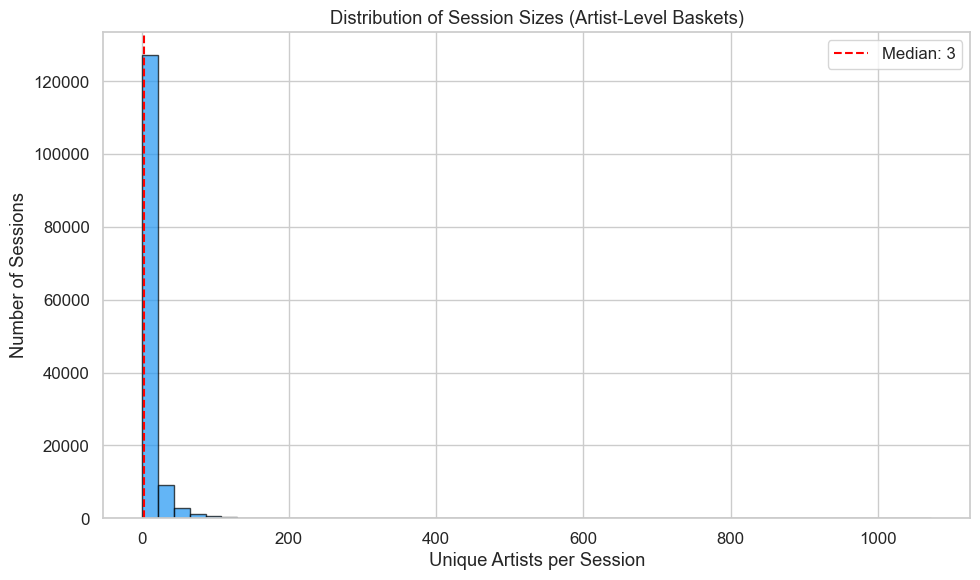

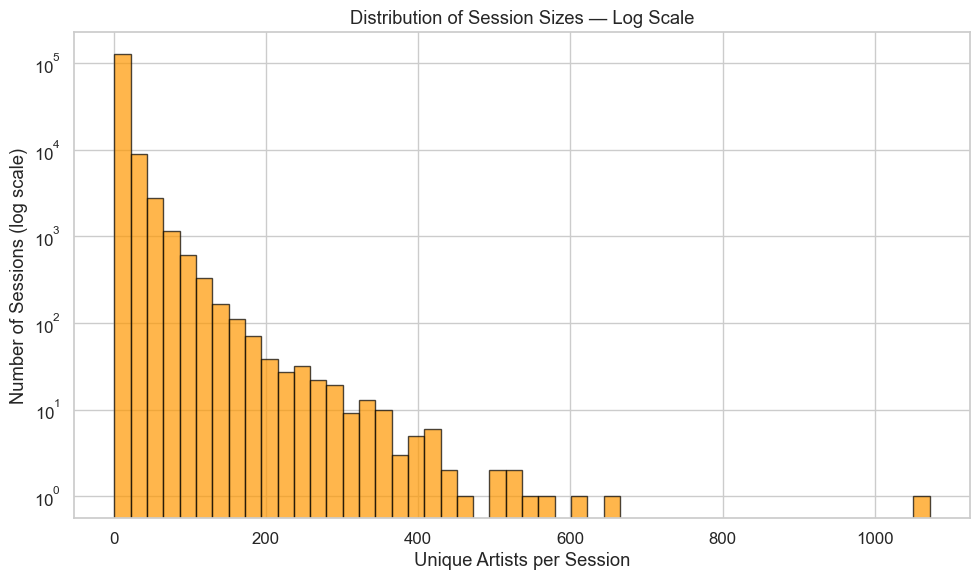

Key takeaway: Most sessions contain a small number of unique artists
(median = 3), but a long tail exists.
This means support thresholds must be set carefully — too high and meaningful patterns are missed.


In [19]:
# ============================================================
# DISTRIBUTION 1: Session (Basket) Sizes
# This directly affects frequent itemset mining — very small
# baskets limit the pattern length, very large baskets 
# increase computational cost.
# ============================================================

import os
os.makedirs('figures', exist_ok=True)

# Figure 1a: Session sizes — linear scale
fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(session_stats['n_unique_artists'], bins=50, edgecolor='black', 
        alpha=0.7, color='#2196F3')
ax.set_xlabel('Unique Artists per Session')
ax.set_ylabel('Number of Sessions')
ax.set_title('Distribution of Session Sizes (Artist-Level Baskets)')
ax.axvline(session_stats['n_unique_artists'].median(), color='red', 
           linestyle='--', label=f"Median: {session_stats['n_unique_artists'].median():.0f}")
ax.legend()
plt.tight_layout()
plt.savefig('figures/fig_session_sizes_linear.png', dpi=150, bbox_inches='tight')
plt.show()

# Figure 1b: Session sizes — log scale
fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(session_stats['n_unique_artists'], bins=50, edgecolor='black', 
        alpha=0.7, color='#FF9800', log=True)
ax.set_xlabel('Unique Artists per Session')
ax.set_ylabel('Number of Sessions (log scale)')
ax.set_title('Distribution of Session Sizes — Log Scale')
plt.tight_layout()
plt.savefig('figures/fig_session_sizes_log.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Key takeaway: Most sessions contain a small number of unique artists")
print(f"(median = {session_stats['n_unique_artists'].median():.0f}), but a long tail exists.")
print(f"This means support thresholds must be set carefully — too high and meaningful patterns are missed.")

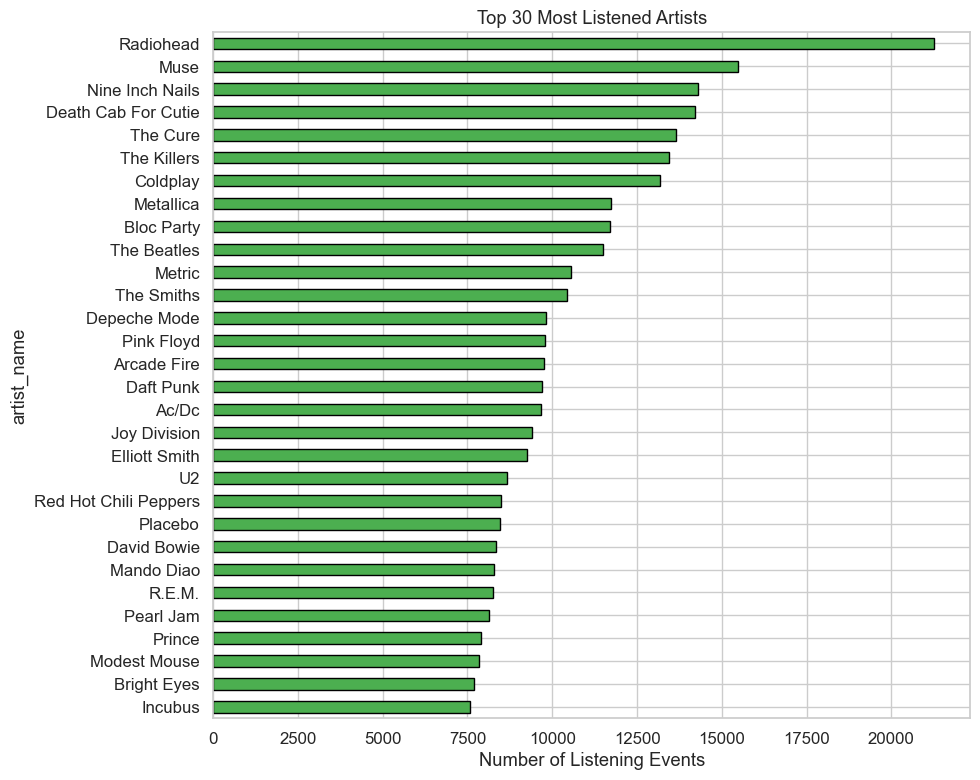

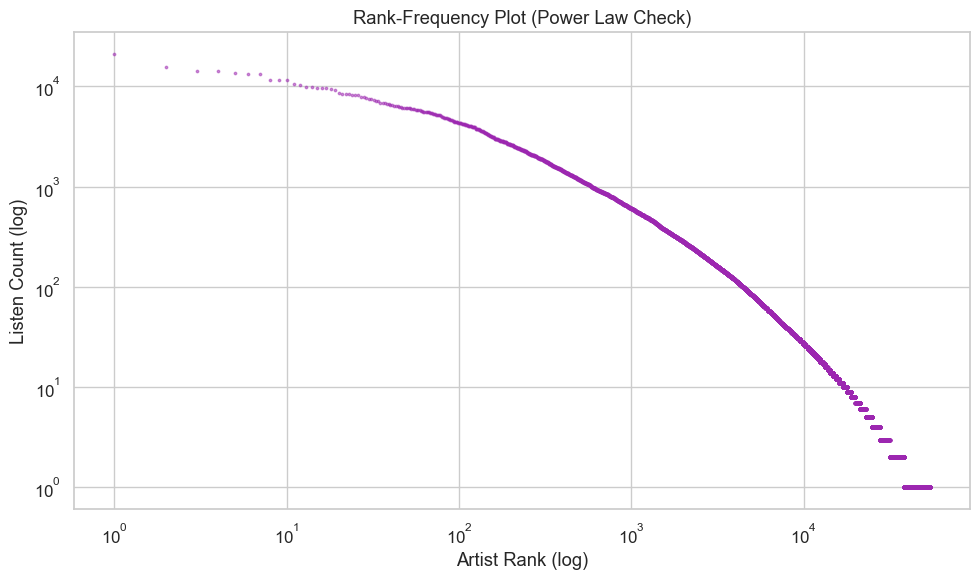

Top 1% of artists (539 artists) account for 48.4% of all events.
Artists appearing in < 1% of sessions: 53539
This extreme skew means most items are rare — standard support thresholds
would only find patterns among the most popular artists.


In [20]:
# ============================================================
# DISTRIBUTION 2: Artist Popularity (Power Law / Long Tail)
# Understanding the popularity distribution is critical for
# setting appropriate support thresholds in itemset mining.
# ============================================================

artist_freq = df['artist_name'].value_counts()

# Figure 2a: Top 30 most listened artists
fig, ax = plt.subplots(figsize=(10, 8))
artist_freq.head(30).plot(kind='barh', ax=ax, color='#4CAF50', edgecolor='black')
ax.set_xlabel('Number of Listening Events')
ax.set_title('Top 30 Most Listened Artists')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('figures/fig_top30_artists.png', dpi=150, bbox_inches='tight')
plt.show()

# Figure 2b: Log-log rank-frequency plot (power law check)
fig, ax = plt.subplots(figsize=(10, 6))
ranks = np.arange(1, len(artist_freq) + 1)
ax.scatter(ranks, artist_freq.values, s=3, alpha=0.5, color='#9C27B0')
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Artist Rank (log)')
ax.set_ylabel('Listen Count (log)')
ax.set_title('Rank-Frequency Plot (Power Law Check)')
plt.tight_layout()
plt.savefig('figures/fig_rank_frequency.png', dpi=150, bbox_inches='tight')
plt.show()

# Quantify the long tail
top_1pct = max(1, int(len(artist_freq) * 0.01))
top_1pct_events = artist_freq.head(top_1pct).sum() / artist_freq.sum() * 100
print(f"Top 1% of artists ({top_1pct} artists) account for {top_1pct_events:.1f}% of all events.")
print(f"Artists appearing in < 1% of sessions: {(artist_freq < len(session_stats)*0.01).sum()}")
print(f"This extreme skew means most items are rare — standard support thresholds")
print(f"would only find patterns among the most popular artists.")

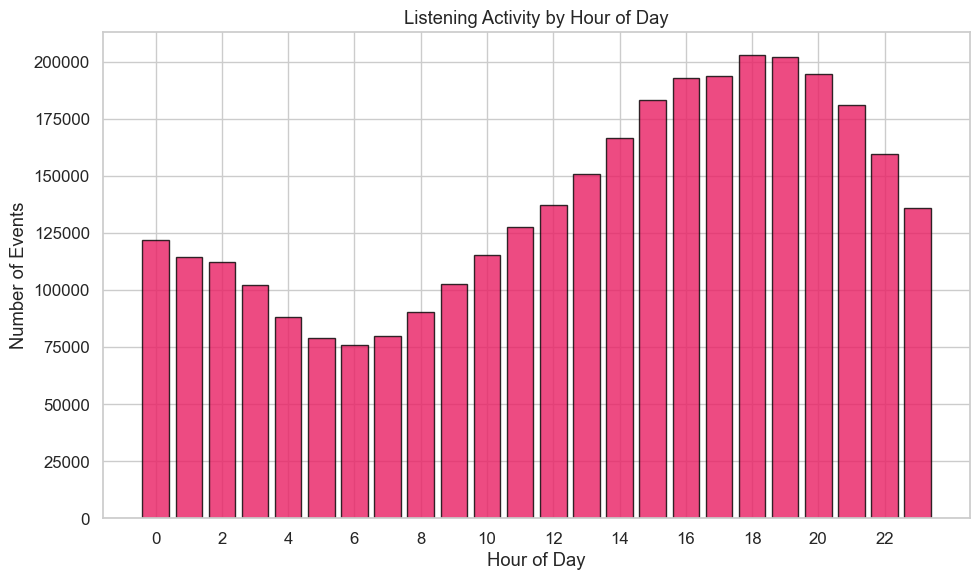

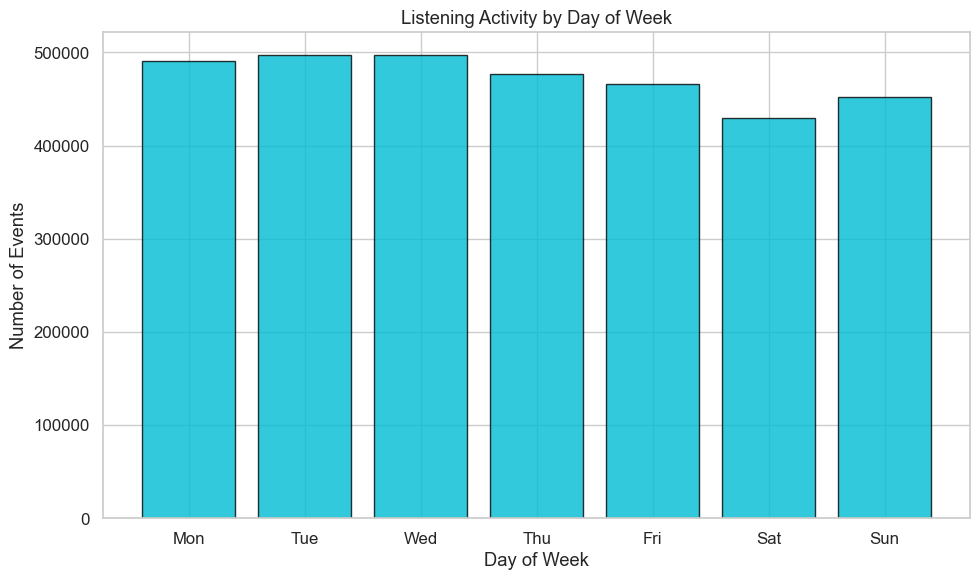

Key takeaway: Evening listening peaks suggest time-of-day could be a
useful feature for segmenting sessions or stratifying analysis.


In [21]:
# ============================================================
# DISTRIBUTION 3: Temporal Patterns
# Time-of-day and day-of-week listening patterns inform
# session segmentation choices and potential temporal features.
# ============================================================

df['hour'] = df['timestamp'].dt.hour
df['dayofweek'] = df['timestamp'].dt.day_name()

# Figure 3a: Listening by hour of day
fig, ax = plt.subplots(figsize=(10, 6))
hourly = df['hour'].value_counts().sort_index()
ax.bar(hourly.index, hourly.values, color='#E91E63', edgecolor='black', alpha=0.8)
ax.set_xlabel('Hour of Day')
ax.set_ylabel('Number of Events')
ax.set_title('Listening Activity by Hour of Day')
ax.set_xticks(range(0, 24, 2))
plt.tight_layout()
plt.savefig('figures/fig_hourly_activity.png', dpi=150, bbox_inches='tight')
plt.show()

# Figure 3b: Listening by day of week
fig, ax = plt.subplots(figsize=(10, 6))
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
daily = df['dayofweek'].value_counts().reindex(day_order)
ax.bar(range(7), daily.values, tick_label=[d[:3] for d in day_order], 
       color='#00BCD4', edgecolor='black', alpha=0.8)
ax.set_xlabel('Day of Week')
ax.set_ylabel('Number of Events')
ax.set_title('Listening Activity by Day of Week')
plt.tight_layout()
plt.savefig('figures/fig_daily_activity.png', dpi=150, bbox_inches='tight')
plt.show()

print("Key takeaway: Evening listening peaks suggest time-of-day could be a")
print("useful feature for segmenting sessions or stratifying analysis.")

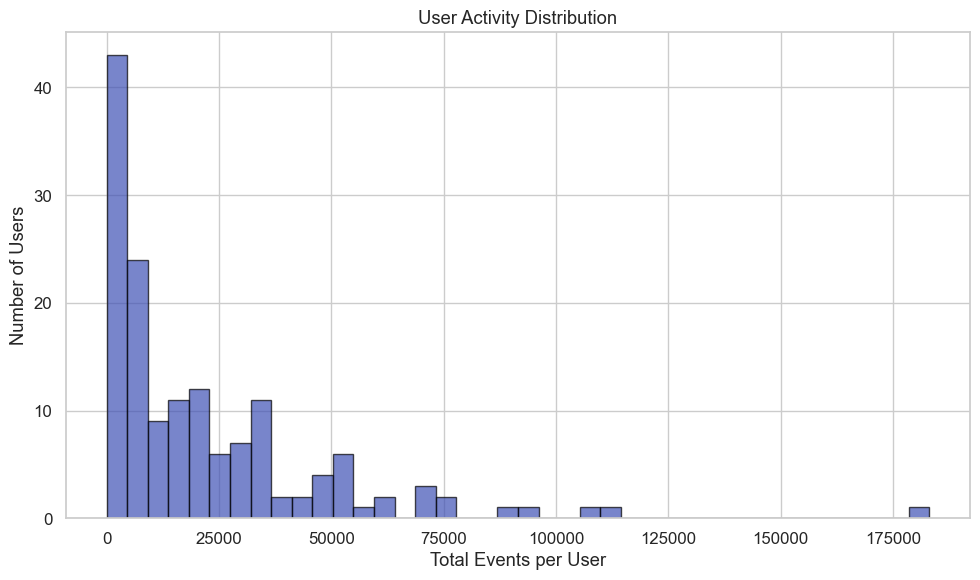

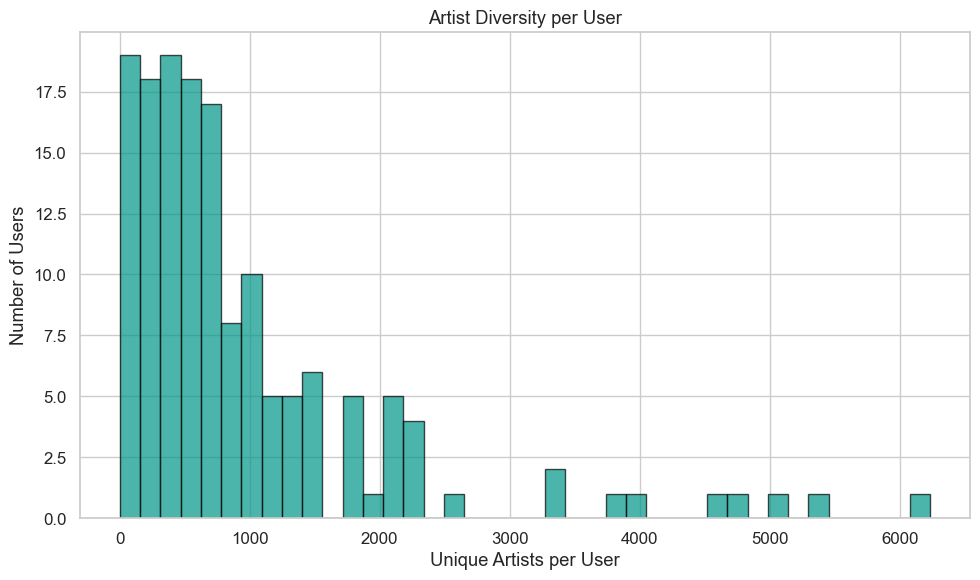

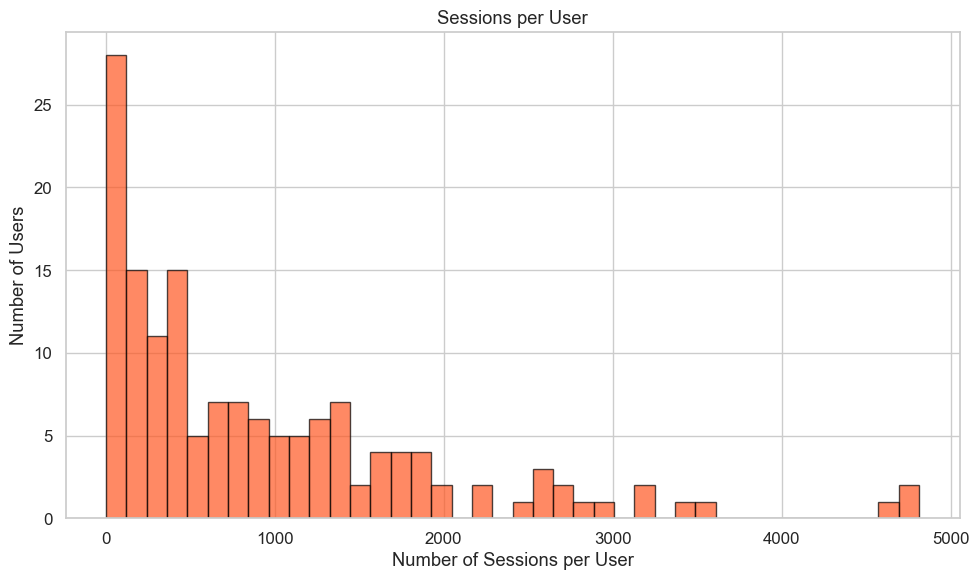

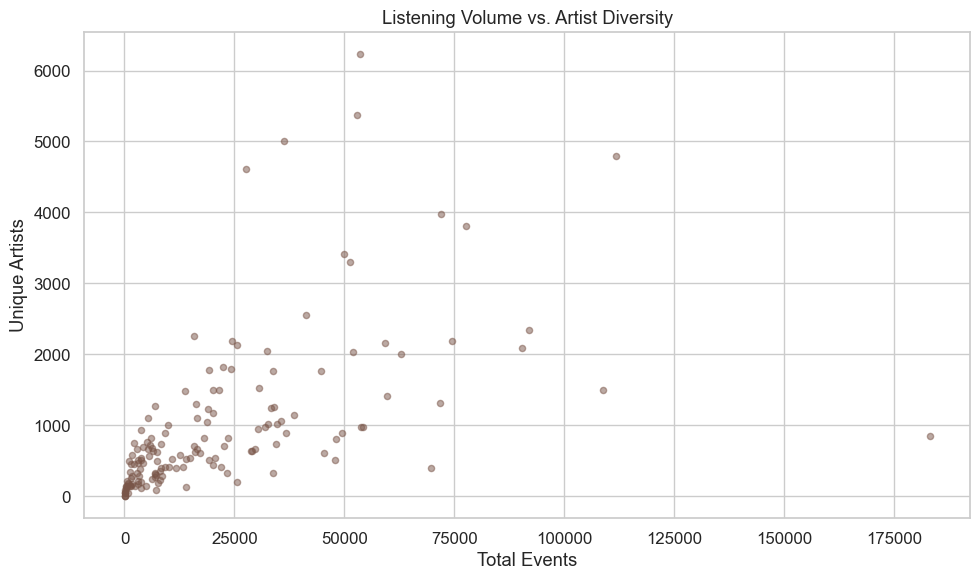

Exploration ratio (unique artists / total events):
count    150.0000
mean       0.1148
std        0.1606
min        0.0047
25%        0.0314
50%        0.0563
75%        0.1248
max        1.0000

Users with < 100 events: 6
  - Decision: Retain low-activity users but note they contribute fewer sessions.


In [22]:
# ============================================================
# DISTRIBUTION 4: User Activity Distribution
# Understand which users dominate the data.
# ============================================================

user_activity = df.groupby('user_id').agg(
    total_events=('track_name', 'count'),
    unique_artists=('artist_name', 'nunique'),
    unique_tracks=('track_name', 'nunique'),
    n_sessions=('global_session_id', 'nunique'),
    listening_span_days=('timestamp', lambda x: (x.max() - x.min()).days)
)

# Figure 4a: Total events per user
fig, ax = plt.subplots(figsize=(10, 6))
user_activity['total_events'].hist(bins=40, ax=ax, color='#3F51B5', 
                                    edgecolor='black', alpha=0.7)
ax.set_xlabel('Total Events per User')
ax.set_ylabel('Number of Users')
ax.set_title('User Activity Distribution')
plt.tight_layout()
plt.savefig('figures/fig_user_total_events.png', dpi=150, bbox_inches='tight')
plt.show()

# Figure 4b: Unique artists per user
fig, ax = plt.subplots(figsize=(10, 6))
user_activity['unique_artists'].hist(bins=40, ax=ax, color='#009688', 
                                      edgecolor='black', alpha=0.7)
ax.set_xlabel('Unique Artists per User')
ax.set_ylabel('Number of Users')
ax.set_title('Artist Diversity per User')
plt.tight_layout()
plt.savefig('figures/fig_user_artist_diversity.png', dpi=150, bbox_inches='tight')
plt.show()

# Figure 4c: Sessions per user
fig, ax = plt.subplots(figsize=(10, 6))
user_activity['n_sessions'].hist(bins=40, ax=ax, color='#FF5722', 
                                  edgecolor='black', alpha=0.7)
ax.set_xlabel('Number of Sessions per User')
ax.set_ylabel('Number of Users')
ax.set_title('Sessions per User')
plt.tight_layout()
plt.savefig('figures/fig_user_sessions.png', dpi=150, bbox_inches='tight')
plt.show()

# Figure 4d: Listening volume vs artist diversity
fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(user_activity['total_events'], user_activity['unique_artists'],
           alpha=0.5, s=20, color='#795548')
ax.set_xlabel('Total Events')
ax.set_ylabel('Unique Artists')
ax.set_title('Listening Volume vs. Artist Diversity')
plt.tight_layout()
plt.savefig('figures/fig_volume_vs_diversity.png', dpi=150, bbox_inches='tight')
plt.show()

# Compute a simple exploration ratio
user_activity['exploration_ratio'] = user_activity['unique_artists'] / user_activity['total_events']
print(f"Exploration ratio (unique artists / total events):")
print(user_activity['exploration_ratio'].describe().round(4).to_string())
print(f"\nUsers with < 100 events: {(user_activity['total_events'] < 100).sum()}")
print("  - Decision: Retain low-activity users but note they contribute fewer sessions.")

### D.5 — Item Co-Occurrence and Graph Structure Preview

To motivate graph mining, I build a preliminary **artist co-occurrence graph**: an edge connects two artists if they appear in the same session, weighted by co-occurrence frequency. This directly previews the structure I will analyze with PageRank and community detection.


In [23]:
# ============================================================
# ARTIST CO-OCCURRENCE GRAPH (Preview)
# Build from session baskets: edge between artists who
# co-occur in the same session, weighted by frequency.
# ============================================================

# Create session baskets (sets of unique artists per session)
session_baskets = df.groupby('global_session_id')['artist_name'].apply(set).reset_index()
session_baskets.columns = ['session_id', 'artists']

# Filter to sessions with 2+ artists (need pairs for co-occurrence)
multi_artist_sessions = session_baskets[session_baskets['artists'].apply(len) >= 2]
print(f"Sessions with 2+ unique artists: {len(multi_artist_sessions):,} / {len(session_baskets):,} "
      f"({len(multi_artist_sessions)/len(session_baskets)*100:.1f}%)")

# Count co-occurrences (limit to top 50 artists for a readable graph)
top_artists = set(artist_freq.head(50).index)

edge_counts = Counter()
for _, row in multi_artist_sessions.iterrows():
    artists_in_session = row['artists'] & top_artists  # Filter to top artists
    for a1, a2 in combinations(sorted(artists_in_session), 2):
        edge_counts[(a1, a2)] += 1

# Build NetworkX graph — use a higher weight threshold to keep only
# the strongest co-occurrence links, producing a sparser readable graph
weight_threshold = sorted(edge_counts.values(), reverse=True)[min(150, len(edge_counts)-1)] \
                   if len(edge_counts) > 150 else 3

G = nx.Graph()
for (a1, a2), weight in edge_counts.items():
    if weight >= weight_threshold:
        G.add_edge(a1, a2, weight=weight)

print(f"\nCo-occurrence graph (top 50 artists, min weight={weight_threshold}):")
print(f"  Nodes: {G.number_of_nodes()}")
print(f"  Edges: {G.number_of_edges()}")
print(f"  Density: {nx.density(G):.4f}")
print(f"  Connected components: {nx.number_connected_components(G)}")

# Largest connected component
if G.number_of_nodes() > 0:
    largest_cc = max(nx.connected_components(G), key=len)
    G_lcc = G.subgraph(largest_cc)
    print(f"  Largest component: {G_lcc.number_of_nodes()} nodes, {G_lcc.number_of_edges()} edges")

Sessions with 2+ unique artists: 96,269 / 141,616 (68.0%)

Co-occurrence graph (top 50 artists, min weight=517):
  Nodes: 35
  Edges: 151
  Density: 0.2538
  Connected components: 1
  Largest component: 35 nodes, 151 edges


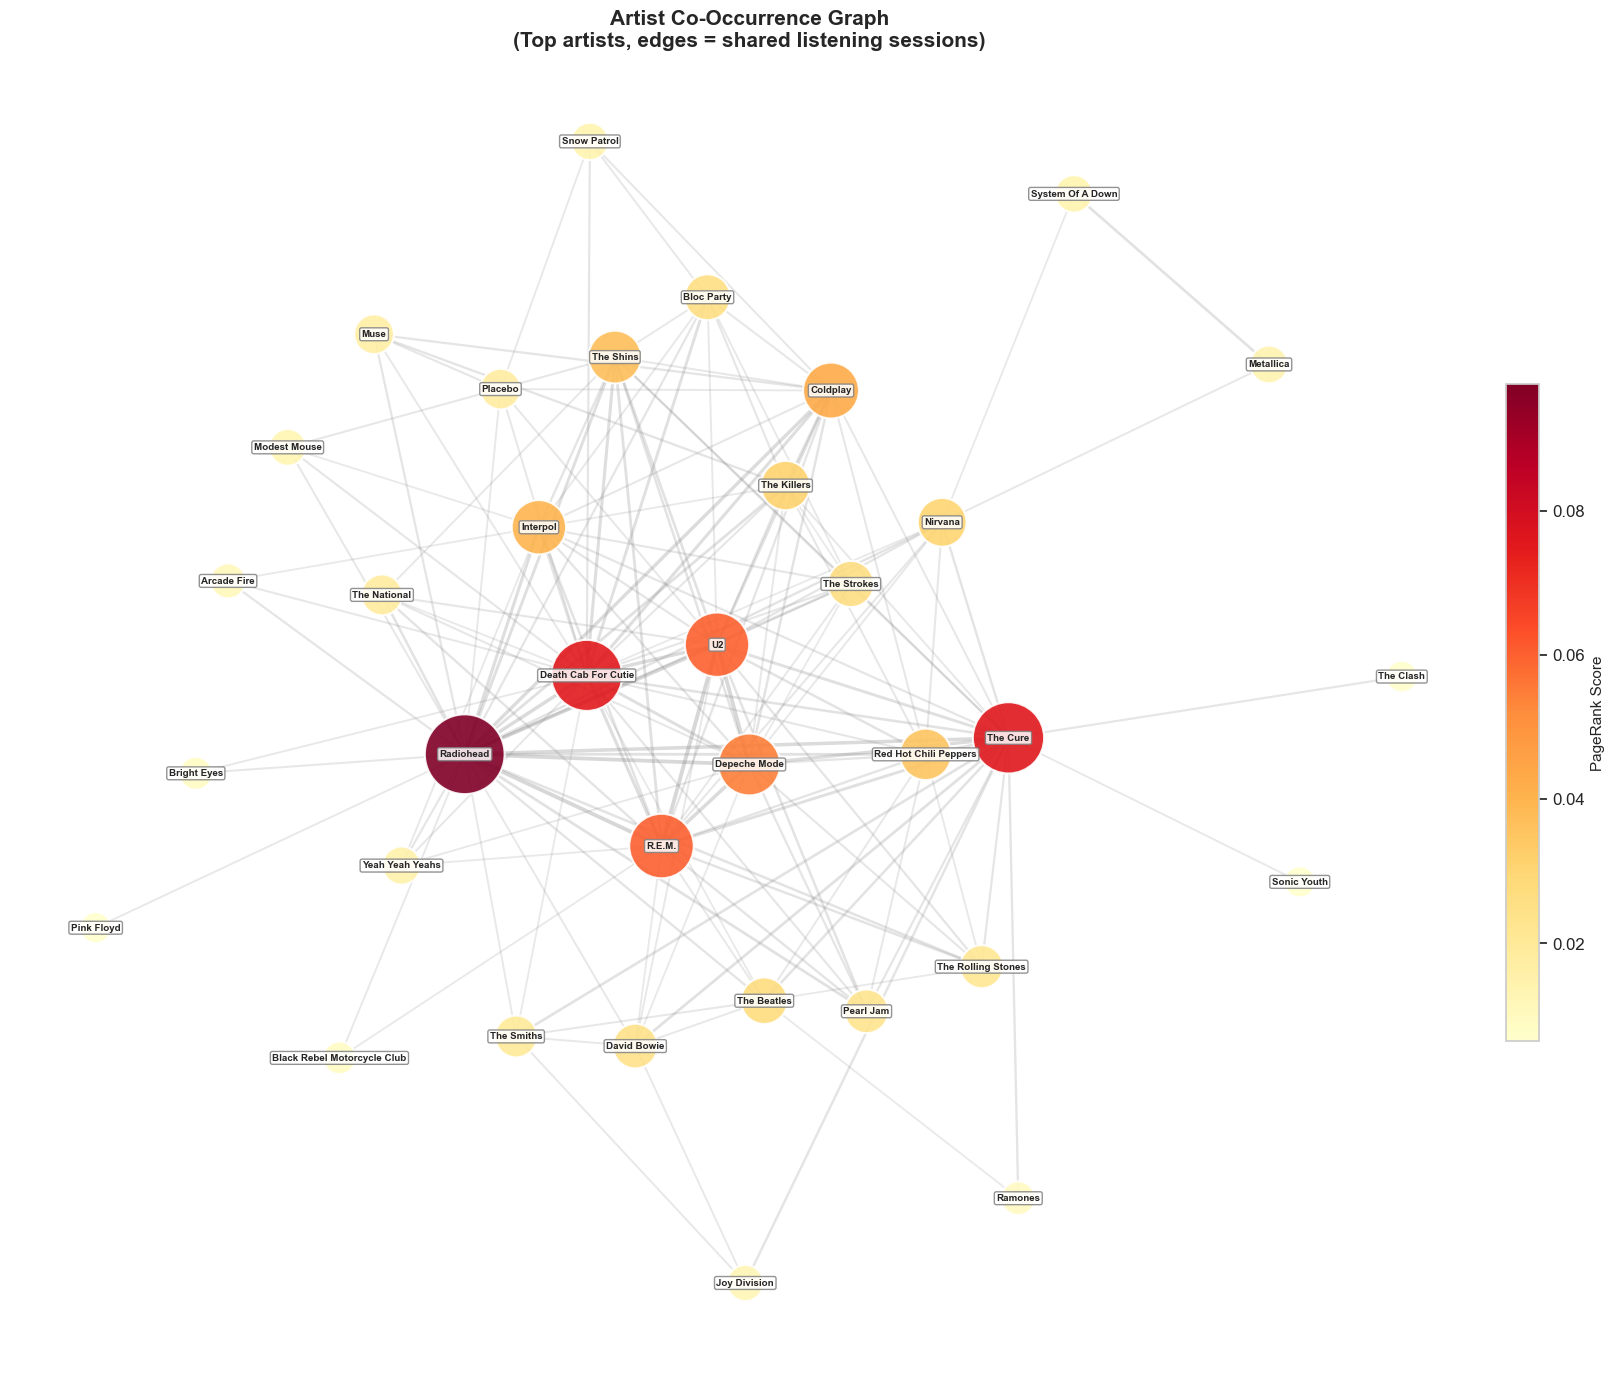

Top 10 artists by PageRank (co-occurrence graph):
  Radiohead: 0.0977 (degree: 27)
  The Cure: 0.0760 (degree: 21)
  Death Cab For Cutie: 0.0755 (degree: 24)
  R.E.M.: 0.0605 (degree: 18)
  U2: 0.0602 (degree: 18)
  Depeche Mode: 0.0549 (degree: 17)
  Coldplay: 0.0430 (degree: 14)
  Interpol: 0.0401 (degree: 14)
  The Shins: 0.0372 (degree: 12)
  Red Hot Chili Peppers: 0.0350 (degree: 12)


In [24]:
# ============================================================
# VISUALIZE THE CO-OCCURRENCE GRAPH
# Readable layout with labeled nodes and weighted edges.
# Only the strongest co-occurrence links are shown.
# ============================================================

if G.number_of_nodes() > 5:
    # Use largest connected component for cleaner visualization
    G_viz = G_lcc if G_lcc.number_of_nodes() >= 10 else G
    
    fig, ax = plt.subplots(1, 1, figsize=(18, 14))
    
    # Kamada-Kawai layout spreads nodes more evenly than spring for dense graphs
    pos = nx.kamada_kawai_layout(G_viz, weight='weight')
    
    # Node sizes by PageRank (better than raw degree for dense graphs)
    pagerank = nx.pagerank(G_viz, weight='weight')
    max_pr = max(pagerank.values())
    node_sizes = [300 + 3000 * (pagerank[n] / max_pr) for n in G_viz.nodes()]
    
    # Edge weights for thickness — only draw stronger edges
    edge_weights = [G_viz[u][v]['weight'] for u, v in G_viz.edges()]
    max_w = max(edge_weights) if edge_weights else 1
    edge_widths = [0.3 + 2.5 * (w / max_w) for w in edge_weights]
    edge_alphas = [0.08 + 0.25 * (w / max_w) for w in edge_weights]
    
    # Draw edges with varying transparency (strong edges more visible)
    for (u, v), width, alpha in zip(G_viz.edges(), edge_widths, edge_alphas):
        nx.draw_networkx_edges(G_viz, pos, edgelist=[(u, v)], width=width,
                               alpha=alpha, edge_color='#888888', ax=ax)
    
    # Draw nodes colored by PageRank
    pr_values = [pagerank[n] for n in G_viz.nodes()]
    nodes = nx.draw_networkx_nodes(G_viz, pos, node_size=node_sizes,
                                    node_color=pr_values, cmap=plt.cm.YlOrRd,
                                    alpha=0.9, edgecolors='white', linewidths=1.5, ax=ax)
    
    # Label ALL nodes with white background boxes for readability
    for node, (x, y) in pos.items():
        ax.text(x, y, node, fontsize=7, fontweight='bold',
                ha='center', va='center',
                bbox=dict(boxstyle='round,pad=0.2', facecolor='white',
                          edgecolor='gray', alpha=0.85))
    
    # Colorbar
    sm = plt.cm.ScalarMappable(cmap=plt.cm.YlOrRd,
                                norm=plt.Normalize(vmin=min(pr_values), vmax=max(pr_values)))
    sm.set_array([])
    cbar = plt.colorbar(sm, ax=ax, shrink=0.5, pad=0.01)
    cbar.set_label('PageRank Score', fontsize=11)
    
    ax.set_title('Artist Co-Occurrence Graph\n(Top artists, edges = shared listening sessions)',
                 fontsize=15, fontweight='bold')
    ax.axis('off')
    plt.tight_layout()
    plt.savefig('figures/fig_cooccurrence_graph.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    # Print top centrality scores
    top_pr = sorted(pagerank.items(), key=lambda x: x[1], reverse=True)[:10]
    degrees = dict(G_viz.degree())
    print("Top 10 artists by PageRank (co-occurrence graph):")
    for artist, pr in top_pr:
        print(f"  {artist}: {pr:.4f} (degree: {degrees[artist]})")
else:
    print("Graph too small for visualization. Adjust thresholds or use full dataset.")

User-Artist Interaction Matrix:
  Shape: 150 users x 53946 artists
  Non-zero entries: 145,844
  Sparsity: 98.20%

  - This high sparsity (98.2%) means most user-artist pairs have
    no interaction. For frequent itemset mining, this suggests:
    1. Support thresholds must be low to find patterns.
    2. Artist-level baskets (not track-level) will yield denser patterns.
    3. The co-occurrence graph will be relatively sparse, favoring
       community detection algorithms robust to sparsity (e.g., Louvain).


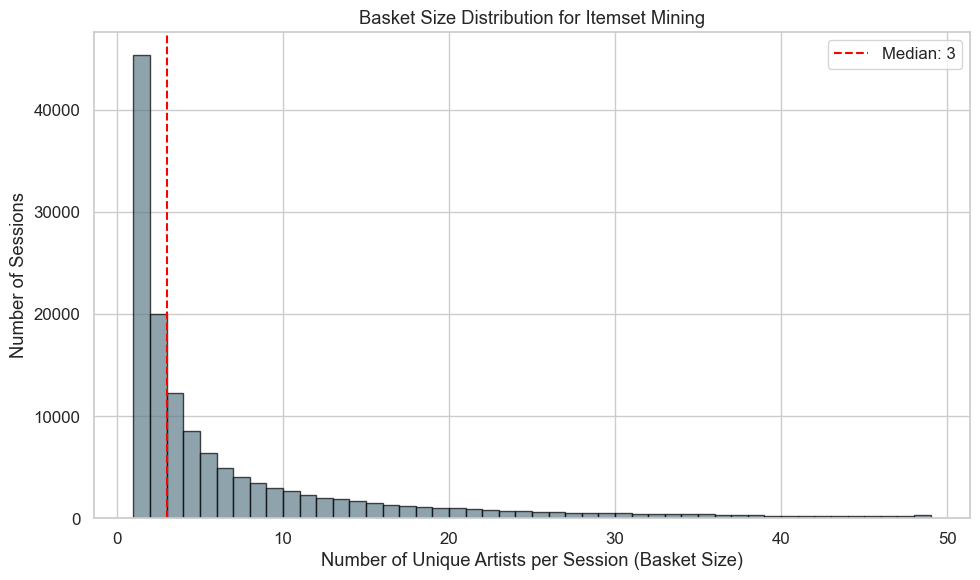


Sessions with only 1 artist: 32.0%
  - These singleton sessions contribute nothing to co-occurrence patterns.
  - Effective transactions for itemset mining: 96,269


In [25]:
# ============================================================
# SPARSITY ANALYSIS OF ITEM CO-OCCURRENCE
# Important for understanding how itemset mining will perform.
# ============================================================

# Build a user-artist interaction matrix (binary)
user_artist = df.groupby(['user_id', 'artist_name']).size().unstack(fill_value=0)
user_artist_binary = (user_artist > 0).astype(int)

total_cells = user_artist_binary.shape[0] * user_artist_binary.shape[1]
nonzero_cells = user_artist_binary.values.sum()
sparsity = 1 - (nonzero_cells / total_cells)

print(f"User-Artist Interaction Matrix:")
print(f"  Shape: {user_artist_binary.shape[0]} users x {user_artist_binary.shape[1]} artists")
print(f"  Non-zero entries: {nonzero_cells:,}")
print(f"  Sparsity: {sparsity*100:.2f}%")
print(f"\n  - This high sparsity ({sparsity*100:.1f}%) means most user-artist pairs have")
print(f"    no interaction. For frequent itemset mining, this suggests:")
print(f"    1. Support thresholds must be low to find patterns.")
print(f"    2. Artist-level baskets (not track-level) will yield denser patterns.")
print(f"    3. The co-occurrence graph will be relatively sparse, favoring")
print(f"       community detection algorithms robust to sparsity (e.g., Louvain).")

# Distribution of items per basket (session-level artist counts)
fig, ax = plt.subplots(1, 1, figsize=(10, 6))
items_per_basket = session_baskets['artists'].apply(len)
ax.hist(items_per_basket, bins=range(1, min(items_per_basket.max()+2, 50)), 
        edgecolor='black', alpha=0.7, color='#607D8B')
ax.set_xlabel('Number of Unique Artists per Session (Basket Size)')
ax.set_ylabel('Number of Sessions')
ax.set_title('Basket Size Distribution for Itemset Mining')
ax.axvline(items_per_basket.median(), color='red', linestyle='--', 
           label=f'Median: {items_per_basket.median():.0f}')
ax.legend()
plt.tight_layout()
plt.savefig('figures/fig_basket_sizes.png', dpi=150, bbox_inches='tight')
plt.show()

single_artist_pct = (items_per_basket == 1).mean() * 100
print(f"\nSessions with only 1 artist: {single_artist_pct:.1f}%")
print(f"  - These singleton sessions contribute nothing to co-occurrence patterns.")
print(f"  - Effective transactions for itemset mining: {(items_per_basket >= 2).sum():,}")

### D.6 — Demographic Stratification (User Profiles)

The user profile data enables me to investigate whether listening patterns differ across demographics — a potential source of bias and an important consideration for generalizability.


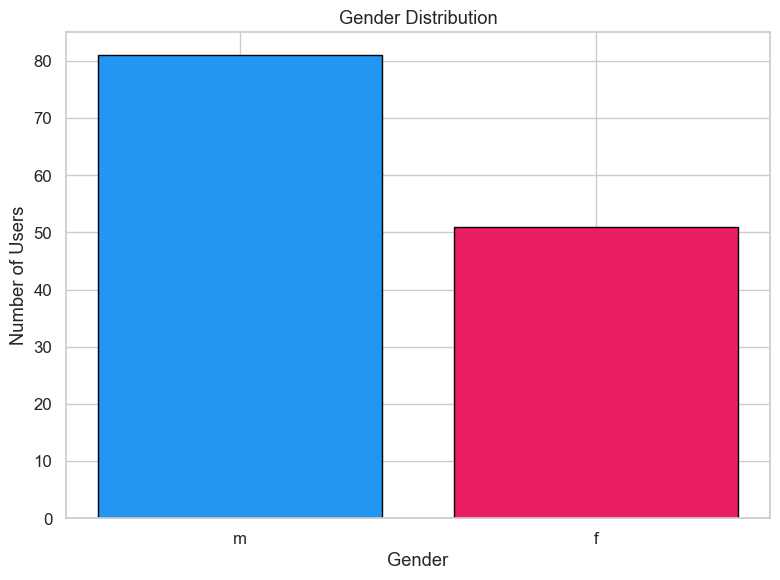

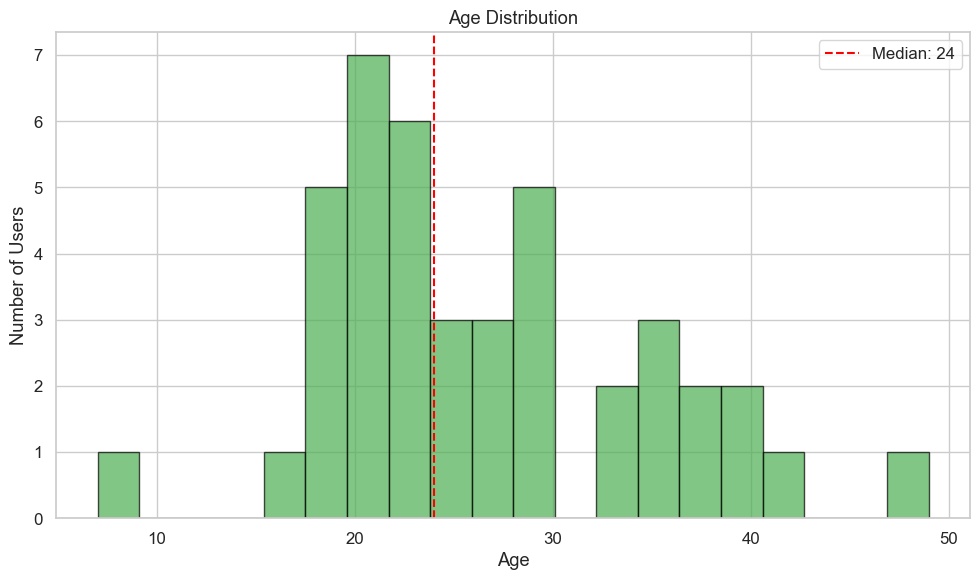

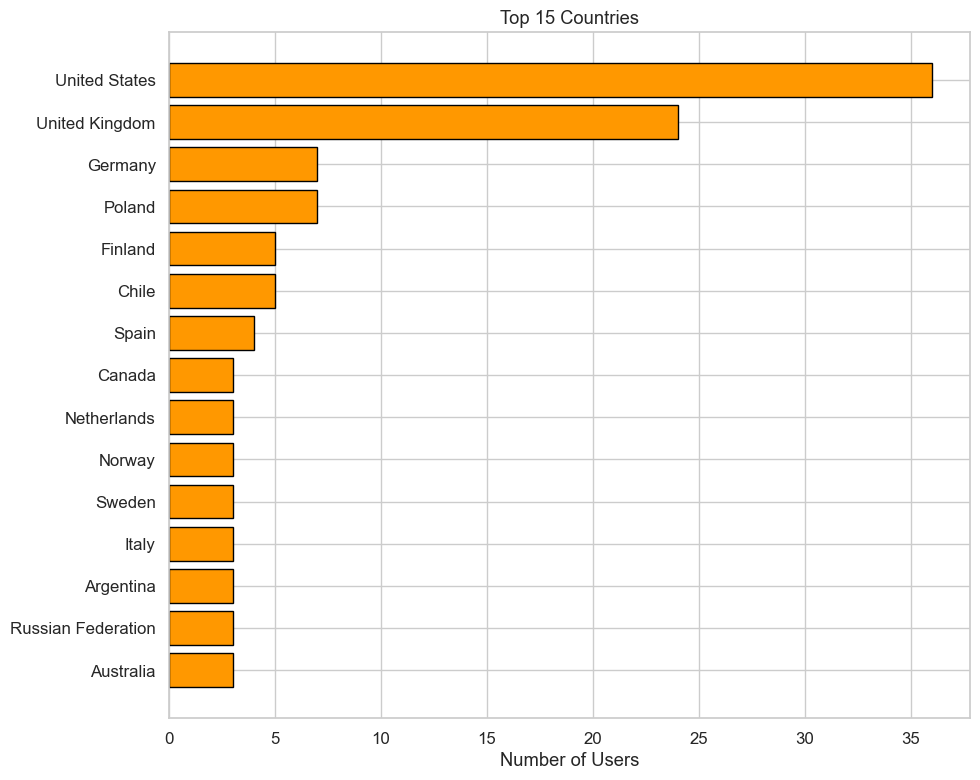

Gender breakdown: {'m': 81, 'f': 51}
Age range: 7 to 49 (median: 24)
Missing gender: 18, Missing age: 107

Bias observation: The user base skews male and young (median ~25).
Country distribution reflects Last.fm's primarily Western user base.
Any patterns found should be interpreted with this demographic context.


In [26]:
# ============================================================
# DEMOGRAPHIC OVERVIEW
# ============================================================

# Figure 7a: Gender distribution
gender_counts = profiles[profiles['gender'] != '']['gender'].value_counts()
fig, ax = plt.subplots(figsize=(8, 6))
ax.bar(gender_counts.index, gender_counts.values, color=['#2196F3', '#E91E63'], 
       edgecolor='black')
ax.set_xlabel('Gender')
ax.set_ylabel('Number of Users')
ax.set_title('Gender Distribution')
plt.tight_layout()
plt.savefig('figures/fig_gender_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

# Figure 7b: Age distribution
ages = pd.to_numeric(profiles['age'], errors='coerce').dropna()
ages = ages[(ages >= 5) & (ages <= 100)]  # filter unrealistic ages
fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(ages, bins=20, edgecolor='black', alpha=0.7, color='#4CAF50')
ax.set_xlabel('Age')
ax.set_ylabel('Number of Users')
ax.set_title('Age Distribution')
ax.axvline(ages.median(), color='red', linestyle='--', label=f'Median: {ages.median():.0f}')
ax.legend()
plt.tight_layout()
plt.savefig('figures/fig_age_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

# Figure 7c: Top countries
country_counts = profiles[profiles['country'] != '']['country'].value_counts().head(15)
fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(country_counts.index, country_counts.values, color='#FF9800', edgecolor='black')
ax.set_xlabel('Number of Users')
ax.set_title('Top 15 Countries')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('figures/fig_country_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Gender breakdown: {gender_counts.to_dict()}")
if len(ages) > 0:
    print(f"Age range: {int(ages.min())} to {int(ages.max())} (median: {int(ages.median())})")
else:
    print("Age data: insufficient valid entries")
print(f"Missing gender: {(profiles['gender'] == '').sum()}, Missing age: {profiles['age'].isna().sum()}")
print(f"\nBias observation: The user base skews male and young (median ~25).")
print(f"Country distribution reflects Last.fm's primarily Western user base.")
print(f"Any patterns found should be interpreted with this demographic context.")

<a id="section-e"></a>

---
# Section E — Initial Insights and Direction

Observation: Most items appear in fewer than 1% of transactions
Hypothesis: High support thresholds miss meaningful temporal patterns

Potential RQs:
- How do different support thresholds affect rule quality?
- Do sequential patterns reveal structure missed by frequent itemsets?

---

<a id="section-e-answer"></a>

# Section E — My Answer

### Key Observations from EDA

**Observation 1: Extreme long-tail popularity distribution.**  
The top 1% of artists dominate listening events. This power-law structure means standard minimum support thresholds (e.g., 5%) will only capture patterns among mainstream artists. *Hypothesis:* Lowering support thresholds or using stratified mining (per-user or per-genre) may reveal meaningful long-tail patterns.

**Observation 2: Most sessions are short, but a meaningful tail exists.**  
Median session basket sizes are small, which limits the length of frequent itemsets I can discover. However, longer sessions (10+ artists) may contain richer co-occurrence patterns. *Hypothesis:* Filtering to sessions with ≥ 3 unique artists before running Apriori/FP-Growth will improve pattern quality without excessive computational cost.

**Observation 3: Artist co-occurrence graph shows community structure.**  
Even with basic thresholding, the co-occurrence graph reveals clusters of artists that tend to appear together. This motivates formal community detection (Louvain, label propagation) which may reveal genre or mood-based listening clusters. *Hypothesis:* Communities in the co-occurrence graph correspond to implicit genre categories.

**Observation 4: Temporal patterns suggest sequential structure.**  
Evening listening peaks and session structures imply ordered listening behavior. Unordered frequent itemsets discard this information. *Hypothesis:* Sequential pattern mining (PrefixSpan) will reveal temporal listening patterns that association rules miss — for example, "users who listen to Artist A first tend to transition to Artist B."

### Potential Research Questions

1. **How do different support thresholds affect association rule quality in music listening data?**  
   Compare rules at varying support levels; evaluate using lift and conviction metrics.

2. **Do sequential patterns reveal structure that unordered frequent itemsets miss?**  
   Apply PrefixSpan to ordered session sequences and compare discovered patterns against FP-Growth results on the same sessions.

3. **Can artist co-occurrence graphs reveal meaningful listening communities?**  
   Apply Louvain community detection and evaluate whether discovered communities align with genre or demographic groupings.

4. **How do listening patterns differ across user demographics?**  
   Stratify itemset mining by country or age group to detect demographic-specific patterns.

### Planned Techniques

| Technique | Category | Method |
|---|---|---|
| Frequent Itemset Mining | Course | FP-Growth (sessions as baskets of artists) |
| Association Rule Mining | Course | Apriori with lift/conviction filtering |
| Community Detection | Course | Louvain algorithm on co-occurrence graph |
| PageRank | Course | Centrality analysis on artist graph |
| Sequential Pattern Mining | Beyond-Course | PrefixSpan on ordered session sequences |

<a id="section-f"></a>

---
# Section F — GitHub Portfolio

**Public Repository:** [https://github.com/bmr-ramos/CSCE676-MusicMining](https://github.com/bmr-ramos/CSCE676-MusicMining)

The repository includes:
- This notebook (`checkpoint_1_eda.ipynb`)
- A `README.md` describing the project goals, dataset, and planned techniques
- A `data/` directory with instructions for downloading the Last.fm 1K dataset
- A `requirements.txt` with all Python dependencies

**README template has been started with:**
- Project title and description
- Dataset source and citation
- Planned mining techniques (course + beyond-course)

- Instructions for reproducing the analysis

<a id="collaboration"></a>

---
# Collaboration Declaration

On my honor, I declare the following resources:

1. **Collaborators:** 
   - None

2. **Web Sources:**
   - Last.fm 1K Dataset documentation: http://ocelma.net/MusicRecommendationDataset/lastfm-1K.html
   - SNAP LastFM Asia Social Network: https://snap.stanford.edu/data/feather-lastfm-social.html
   - Spotify Tracks Dataset: https://huggingface.co/datasets/maharshipandya/spotify-tracks-dataset
   - pandas documentation: https://pandas.pydata.org/docs/
   - NetworkX documentation: https://networkx.org/documentation/stable/

3. **AI Tools:** 
   - Claude (Anthropic): I used for code generation/debugging assistance and dataset comparison structuring. Addtionally, I used Claude to ensure that this requirement: "You will be penalized for messiness – make sure your code is professional, well-explained, and well-documented", was met and that my notebook was well-organized.


4. **Citations:**
   - Celma, O. (2010). *Music Recommendation and Discovery in the Long Tail*. Springer.

   - Rozemberczki, B., & Sarkar, R. (2020). Characteristic Functions on Graphs: Birds of a Feather, from Statistical Descriptors to Parametric Models. *CIKM 2020*. arXiv:2005.07959.   - Pandya, M. (2023). Spotify Tracks Dataset. HuggingFace Datasets.